In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('aggregated_dataset.csv', sep = ';')
df.head()

,id,best_rank,avg_rank,total_weeks_charted,first_appearance,last_appearance,Title,Artist,peak_score,longevity_score,popularity_score,popularity_label,split,Danceability,Energy,Loudness_norm,Speechiness,Acousticness,Instrumentalness,Valence
0,000xQL6tZNLJzIrtIgxqSl,40,101.500000,118,2017-03-24,2017-09-12,Still Got Time (feat. PARTYNEXTDOOR),ZAYN,80.5,100.0,92.2,Popular,train,0.748,0.627,0.825120,0.064,0.131,0.0,0.524
1,003VDDA7J3Xb2ZFlNx7nIZ,108,138.000000,2,2020-02-07,2020-02-08,YELL OH,Trippie Redd,46.5,10.0,24.6,Not Popular,train,0.842,0.578,0.824511,0.138,0.004,0.0,0.190
2,003eoIwxETJujVWmNFMoZy,91,136.500000,14,2018-06-15,2018-06-28,Growing Pains,Alessia Cara,55.0,70.0,64.0,Not Popular,train,0.353,0.755,0.817955,0.733,0.082,0.0,0.437
3,003vvx7Niy0yvhvHt4a68B,73,168.069643,560,2020-08-15,2023-01-01,Mr. Brightside,The Killers,64.0,100.0,85.6,Popular,train,0.352,0.911,0.848296,0.075,0.001,0.0,0.236
4,00B7TZ0Xawar6NZ00JFomN,61,109.285714,14,2018-04-06,2018-04-19,Best Life (feat. Chance The Rapper),Cardi B,70.0,70.0,70.0,Not Popular,train,0.620,0.625,0.784249,0.553,0.287,0.0,0.665


In [5]:
print(df.shape)

(9161, 20)


In [10]:
df[df["total_weeks_charted"] == 1].count()

id                     2244
best_rank              2244
avg_rank               2244
total_weeks_charted    2244
first_appearance       2244
last_appearance        2244
Title                  2244
Artist                 2244
peak_score             2244
longevity_score        2244
popularity_score       2244
popularity_label       2244
split                  2244
Danceability           2244
Energy                 2244
Loudness_norm          2244
Speechiness            2244
Acousticness           2244
Instrumentalness       2244
Valence                2244
duration_bucket        2244
dtype: int64

In [16]:
def assign_bucket(weeks):
    if weeks <= 1:
        return "≤ 1 week"
    elif weeks <= 4:
        return "≤ 1 month"
    elif weeks <= 26:
        return "≤ 6 months"
    elif weeks <= 52:
        return "≤ 1 year"
    else:
        return "> 1 year"

df["duration_bucket"] = df["total_weeks_charted"].apply(assign_bucket)

In [17]:
labels = ["≤ 1 week", "≤ 1 month", "≤ 6 months", "≤ 1 year", "> 1 year"]

percentage = (
    df["duration_bucket"]
    .value_counts(normalize=True)
    .reindex(labels, fill_value=0) * 100
)

In [21]:
counts = df["duration_bucket"].value_counts().reindex(labels, fill_value=0)
percentages = (counts / len(df) * 100).round(2)
print("Song Duration Distribution:\n")
for label in labels:
    print(f"{label}: {counts[label]} songs ({percentages[label]}%)")

Song Duration Distribution:

≤ 1 week: 2244 songs (24.5%)
≤ 1 month: 1385 songs (15.12%)
≤ 6 months: 2585 songs (28.22%)
≤ 1 year: 838 songs (9.15%)
> 1 year: 2109 songs (23.02%)


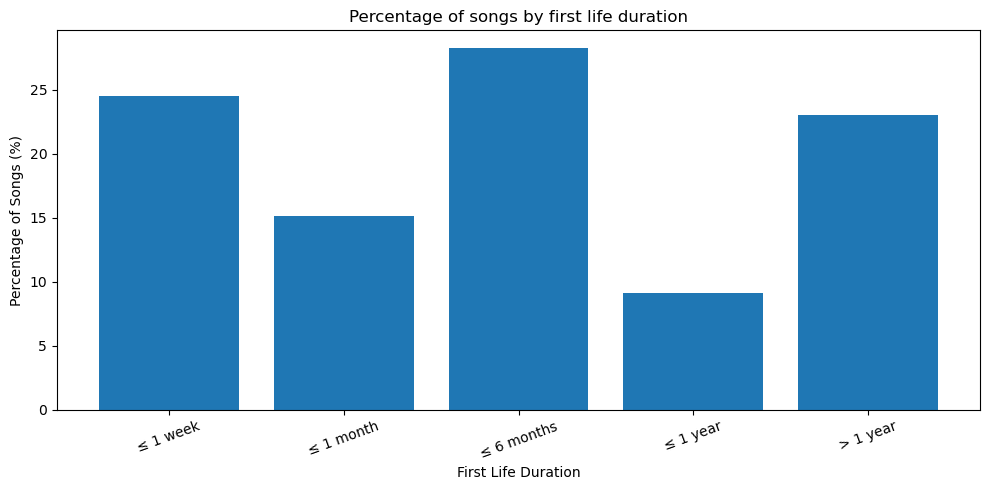

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(percentage.index, percentage.values)
plt.ylabel("Percentage of Songs (%)")
plt.xlabel("First Life Duration")
plt.title("Percentage of songs by first life duration")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

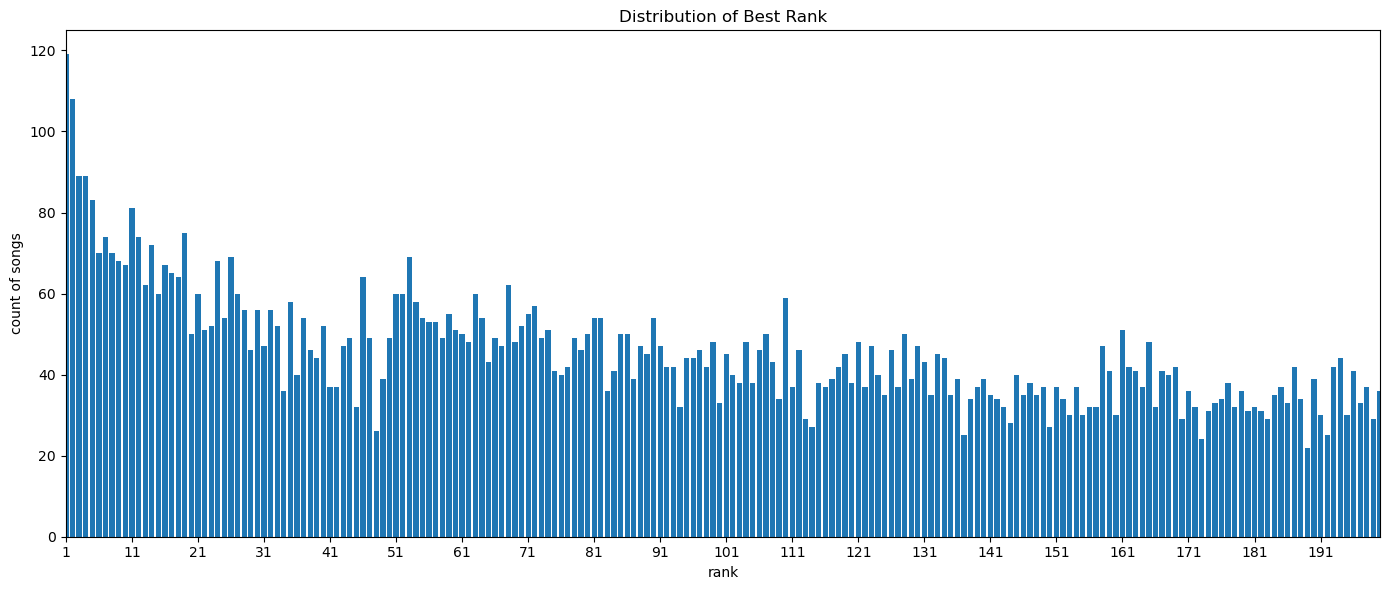

In [31]:
counts = df['best_rank'].value_counts().sort_index()

plt.figure(figsize=(14,6))
plt.bar(counts.index, counts.values)
plt.xlabel("rank")
plt.ylabel("count of songs")
plt.title("Distribution of Best Rank")


plt.xticks(range(1, 201, 10))

plt.xlim(1, 200)
plt.tight_layout()
plt.show()

In [50]:
train = pd.read_csv('X_train.csv')
val = pd.read_csv('X_val.csv', sep = ',')
test = pd.read_csv('X_test.csv', sep = ',')

print(train.shape[0],val.shape[0], test.shape[0])

6158 1414 1589


In [51]:
train.head()

,Danceability,Energy,Loudness_norm,Speechiness,Acousticness,Instrumentalness,Valence,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,artist_song_count,artist_avg_rank,artist_best_rank,num_collab_artists,collab_artist_avg_popularity,collab_max_frequency,collab_avg_frequency
0,0.748,0.627,0.825120,0.064,0.131,0.0,0.524,2017,1,3,4,1,0,13,91.28,2.0,0,0.0,0,0.0
1,0.842,0.578,0.824511,0.138,0.004,0.0,0.190,2020,1,2,4,1,0,51,135.60,28.0,0,0.0,0,0.0
2,0.353,0.755,0.817955,0.733,0.082,0.0,0.437,2018,2,6,4,1,0,8,105.03,18.0,0,0.0,0,0.0
3,0.352,0.911,0.848296,0.075,0.001,0.0,0.236,2020,3,8,5,0,0,6,173.24,73.0,0,0.0,0,0.0
4,0.620,0.625,0.784249,0.553,0.287,0.0,0.665,2018,2,4,4,1,0,22,80.37,1.0,0,0.0,0,0.0


In [53]:
df_all = pd.concat([train, val, test], ignore_index=True)
df_all

,Danceability,Energy,Loudness_norm,Speechiness,Acousticness,Instrumentalness,Valence,release_year,release_quarter,release_month,release_day_of_week,is_friday_release,is_holiday_season,artist_song_count,artist_avg_rank,artist_best_rank,num_collab_artists,collab_artist_avg_popularity,collab_max_frequency,collab_avg_frequency
0,0.748,0.627,0.825120,0.064,0.131,0.000,0.524,2017,1,3,4,1,0,13,91.28,2.0,0,0.0,0,0.0
1,0.842,0.578,0.824511,0.138,0.004,0.000,0.190,2020,1,2,4,1,0,51,135.60,28.0,0,0.0,0,0.0
2,0.353,0.755,0.817955,0.733,0.082,0.000,0.437,2018,2,6,4,1,0,8,105.03,18.0,0,0.0,0,0.0
3,0.352,0.911,0.848296,0.075,0.001,0.000,0.236,2020,3,8,5,0,0,6,173.24,73.0,0,0.0,0,0.0
4,0.620,0.625,0.784249,0.553,0.287,0.000,0.665,2018,2,4,4,1,0,22,80.37,1.0,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9156,0.769,0.684,0.854416,0.041,0.011,0.000,0.835,2023,1,2,0,0,0,5,135.38,46.0,0,0.0,0,0.0
9157,0.723,0.737,0.780537,0.039,0.004,0.003,0.689,2022,3,9,3,0,0,7,134.08,59.0,0,0.0,0,0.0
9158,0.393,0.305,0.670138,0.046,0.765,0.001,0.150,2022,4,11,4,1,1,26,147.53,24.0,0,0.0,0,0.0
9159,0.661,0.354,0.591356,0.142,0.549,0.001,0.123,2022,4,10,4,1,0,174,102.52,1.0,0,0.0,0,0.0


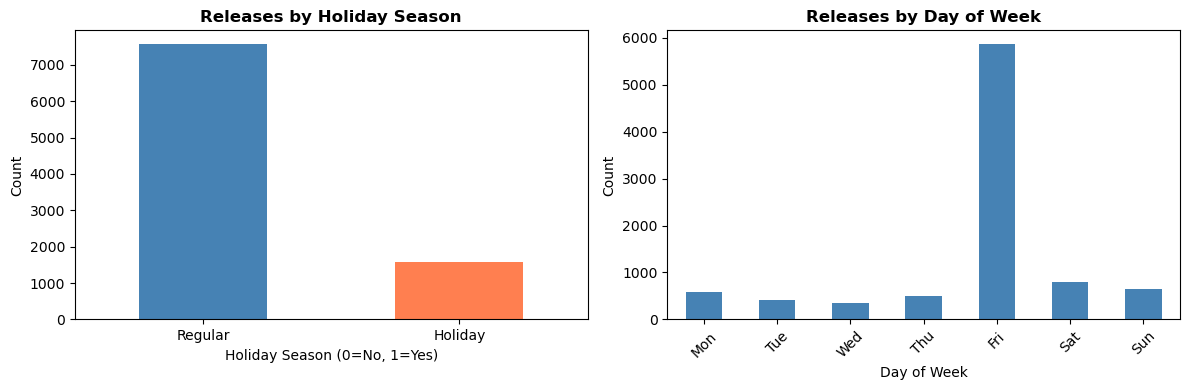


📊 Release Distribution Summary:

Holiday Season:
is_holiday_season
0    7570
1    1591
Name: count, dtype: int64

Day of Week:
release_day_of_week
0     582
1     416
2     341
3     505
4    5864
5     802
6     651
Name: count, dtype: int64


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Holiday season distribution
df_all['is_holiday_season'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Releases by Holiday Season', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Holiday Season (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Regular', 'Holiday'], rotation=0)

# Day of week distribution
df_all['release_day_of_week'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Releases by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRelease Distribution Summary:")
print(f"\nHoliday Season:")
print(df_all['is_holiday_season'].value_counts())
print(f"\nDay of Week:")
print(df_all['release_day_of_week'].value_counts().sort_index())

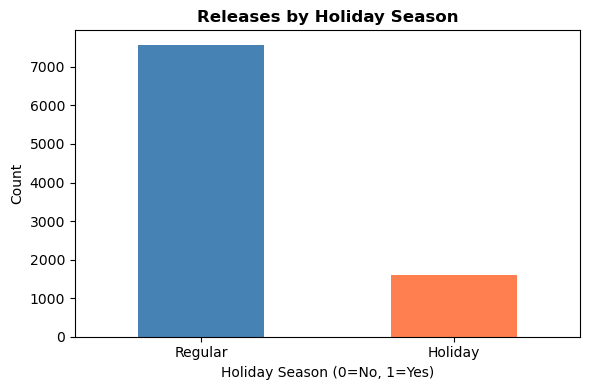

In [73]:
plt.figure(figsize=(6, 4))
df_all['is_holiday_season'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'coral']
)

plt.title('Releases by Holiday Season', fontsize=12, fontweight='bold')
plt.xlabel('Holiday Season (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Regular', 'Holiday'], rotation=0)

plt.tight_layout()
plt.show()

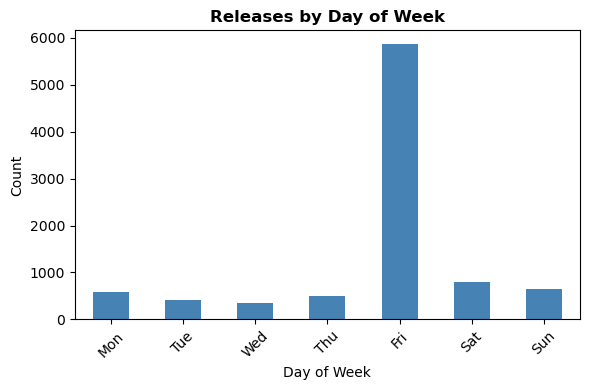

In [74]:
plt.figure(figsize=(6, 4))
df_all['release_day_of_week'].value_counts().sort_index().plot(
    kind='bar',
    color='steelblue'
)

plt.title('Releases by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)

plt.tight_layout()
plt.show()

In [59]:
train_all = pd.read_csv('train_all_feature.csv',sep = ',')
val_all = pd.read_csv('val_all_feature.csv', sep = ',')
test_all = pd.read_csv('test_all_feature.csv', sep = ',')

print(train_all.shape[0],val_all.shape[0], test_all.shape[0])

6158 1414 1589


In [62]:
data_all = pd.concat([train_all, val_all, test_all], ignore_index=True)
data_all.shape

(9161, 34)

ARTIST RECURRENCE & FREQUENCY ANALYSIS

 Overall Statistics:
  - Total unique artists: 1,503
  - Total songs: 9,161
  - Mean songs per artist: 6.10
  - Median songs per artist: 2
  - Max songs by one artist: 211

 Concentration Analysis:
  - Top 10% of artists (150 artists) have 5,444 songs (59.4% of dataset)
  - Top 1% of artists (15 artists) have 1,518 songs


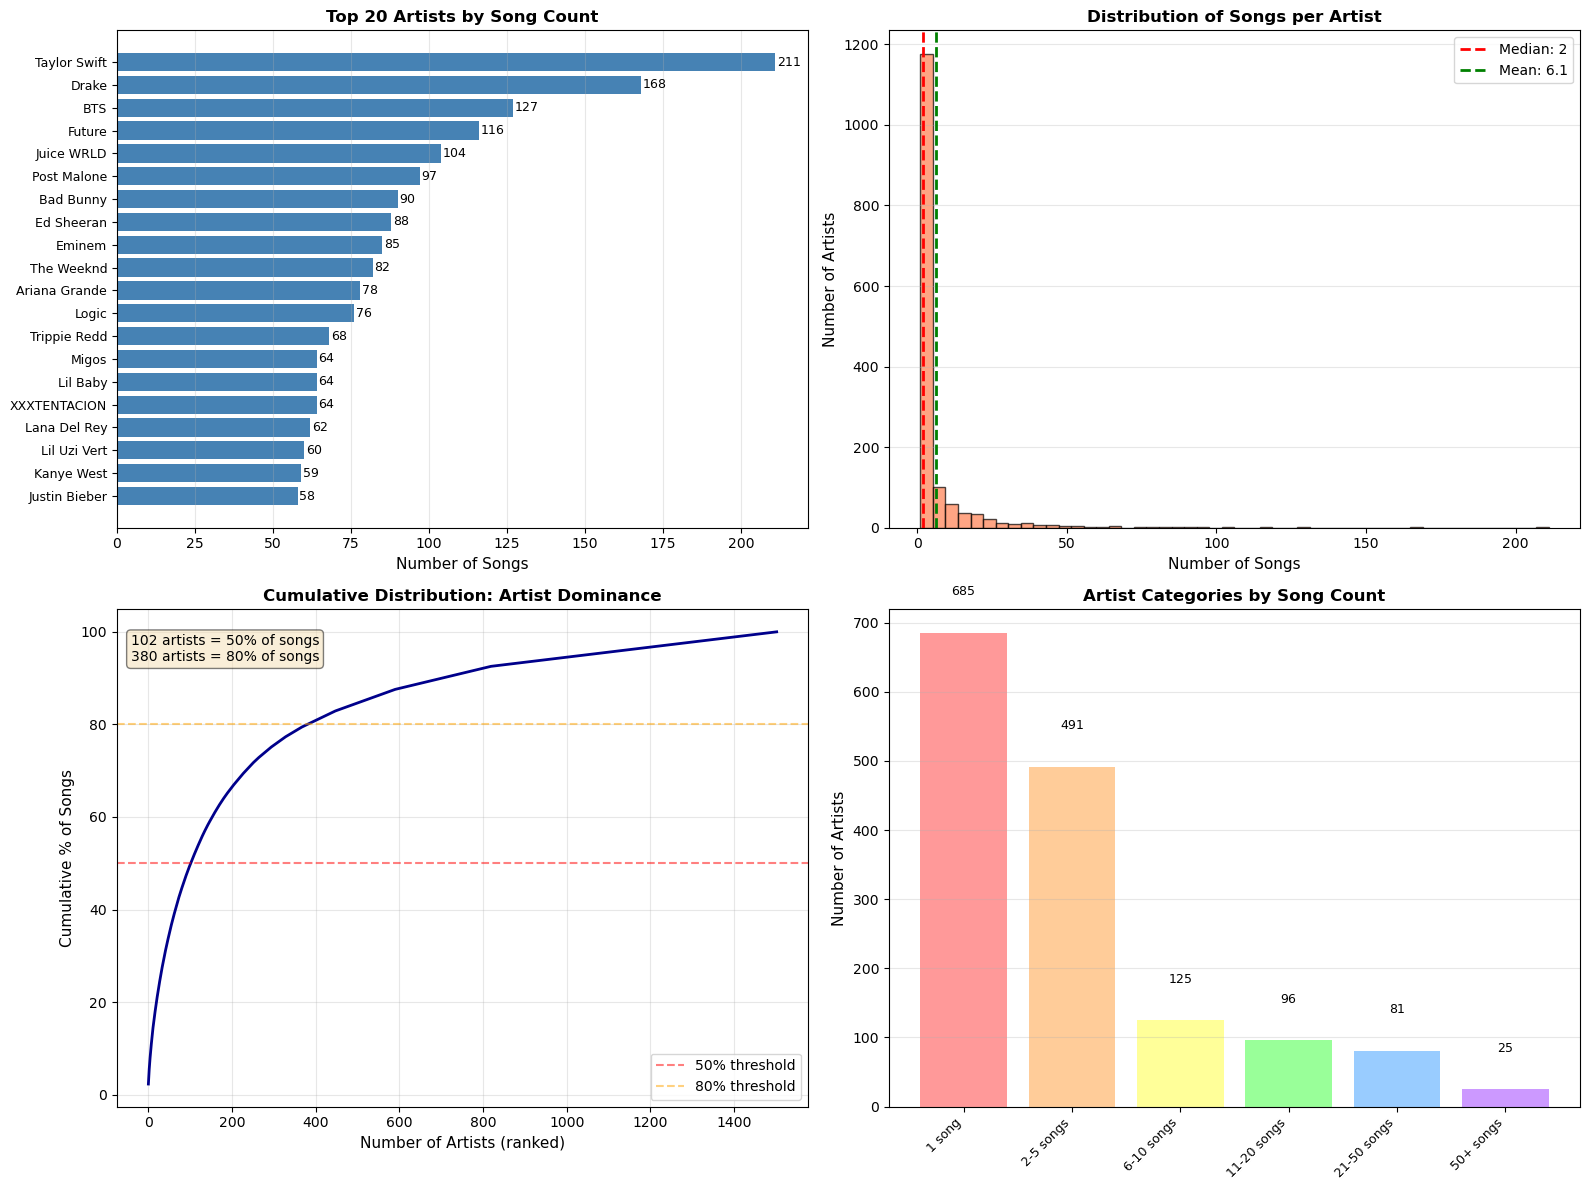

 Top 10 Artists:
   1. Taylor Swift                             : 211 songs
   2. Drake                                    : 168 songs
   3. BTS                                      : 127 songs
   4. Future                                   : 116 songs
   5. Juice WRLD                               : 104 songs
   6. Post Malone                              :  97 songs
   7. Bad Bunny                                :  90 songs
   8. Ed Sheeran                               :  88 songs
   9. Eminem                                   :  85 songs
  10. The Weeknd                               :  82 songs
Artist Category Breakdown:
  - 1 song         :   685 artists ( 45.6%)
  - 2-5 songs      :   491 artists ( 32.7%)
  - 6-10 songs     :   125 artists (  8.3%)
  - 11-20 songs    :    96 artists (  6.4%)
  - 21-50 songs    :    81 artists (  5.4%)
  - 50+ songs      :    25 artists (  1.7%)


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 100)
print("ARTIST RECURRENCE & FREQUENCY ANALYSIS")
print("=" * 100)

# Count songs per artist (using primary artist)
artist_song_counts = data_all['primary_artist'].value_counts()

print(f"\n Overall Statistics:")
print(f"  - Total unique artists: {len(artist_song_counts):,}")
print(f"  - Total songs: {len(data_all):,}")
print(f"  - Mean songs per artist: {artist_song_counts.mean():.2f}")
print(f"  - Median songs per artist: {artist_song_counts.median():.0f}")
print(f"  - Max songs by one artist: {artist_song_counts.max()}")

# Check concentration
top_10_pct = artist_song_counts.head(int(len(artist_song_counts) * 0.1)).sum()
concentration = (top_10_pct / len(data_all)) * 100

print(f"\n Concentration Analysis:")
print(f"  - Top 10% of artists ({int(len(artist_song_counts) * 0.1):,} artists) have {top_10_pct:,} songs ({concentration:.1f}% of dataset)")
print(f"  - Top 1% of artists ({int(len(artist_song_counts) * 0.01):,} artists) have {artist_song_counts.head(int(len(artist_song_counts) * 0.01)).sum():,} songs")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 20 artists by song count
top_20 = artist_song_counts.head(20)
axes[0, 0].barh(range(len(top_20)), top_20.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_20)))
axes[0, 0].set_yticklabels(top_20.index, fontsize=9)
axes[0, 0].set_xlabel('Number of Songs', fontsize=11)
axes[0, 0].set_title('Top 20 Artists by Song Count', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_20.values):
    axes[0, 0].text(v + 0.5, i, str(v), va='center', fontsize=9)

# 2. Distribution of songs per artist (histogram)
axes[0, 1].hist(artist_song_counts.values, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Songs', fontsize=11)
axes[0, 1].set_ylabel('Number of Artists', fontsize=11)
axes[0, 1].set_title('Distribution of Songs per Artist', fontsize=12, fontweight='bold')
axes[0, 1].axvline(artist_song_counts.median(), color='red', linestyle='--', 
                   linewidth=2, label=f'Median: {artist_song_counts.median():.0f}')
axes[0, 1].axvline(artist_song_counts.mean(), color='green', linestyle='--', 
                   linewidth=2, label=f'Mean: {artist_song_counts.mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cumulative distribution
sorted_counts = artist_song_counts.sort_values(ascending=False)
cumsum = sorted_counts.cumsum()
cumsum_pct = (cumsum / cumsum.max()) * 100

axes[1, 0].plot(range(len(cumsum_pct)), cumsum_pct, color='darkblue', linewidth=2)
axes[1, 0].set_xlabel('Number of Artists (ranked)', fontsize=11)
axes[1, 0].set_ylabel('Cumulative % of Songs', fontsize=11)
axes[1, 0].set_title('Cumulative Distribution: Artist Dominance', fontsize=12, fontweight='bold')
axes[1, 0].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[1, 0].axhline(80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Find how many artists account for 50% and 80% of songs
artists_for_50 = (cumsum_pct <= 50).sum()
artists_for_80 = (cumsum_pct <= 80).sum()
axes[1, 0].text(0.02, 0.95, 
                f'{artists_for_50:,} artists = 50% of songs\n{artists_for_80:,} artists = 80% of songs',
                transform=axes[1, 0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Artist frequency categories
categories = pd.cut(artist_song_counts, 
                   bins=[0, 1, 5, 10, 20, 50, artist_song_counts.max()],
                   labels=['1 song', '2-5 songs', '6-10 songs', '11-20 songs', '21-50 songs', '50+ songs'])
category_counts = categories.value_counts().sort_index()

axes[1, 1].bar(range(len(category_counts)), category_counts.values, 
               color=['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#99ccff', '#cc99ff'])
axes[1, 1].set_xticks(range(len(category_counts)))
axes[1, 1].set_xticklabels(category_counts.index, rotation=45, ha='right', fontsize=9)
axes[1, 1].set_ylabel('Number of Artists', fontsize=11)
axes[1, 1].set_title('Artist Categories by Song Count', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(category_counts.values):
    axes[1, 1].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f" Top 10 Artists:")
for i, (artist, count) in enumerate(artist_song_counts.head(10).items(), 1):
    print(f"  {i:2d}. {artist:40s} : {count:3d} songs")

print(f"Artist Category Breakdown:")
for cat, count in category_counts.items():
    pct = (count / len(artist_song_counts)) * 100
    print(f"  - {cat:15s}: {count:5,} artists ({pct:5.1f}%)")

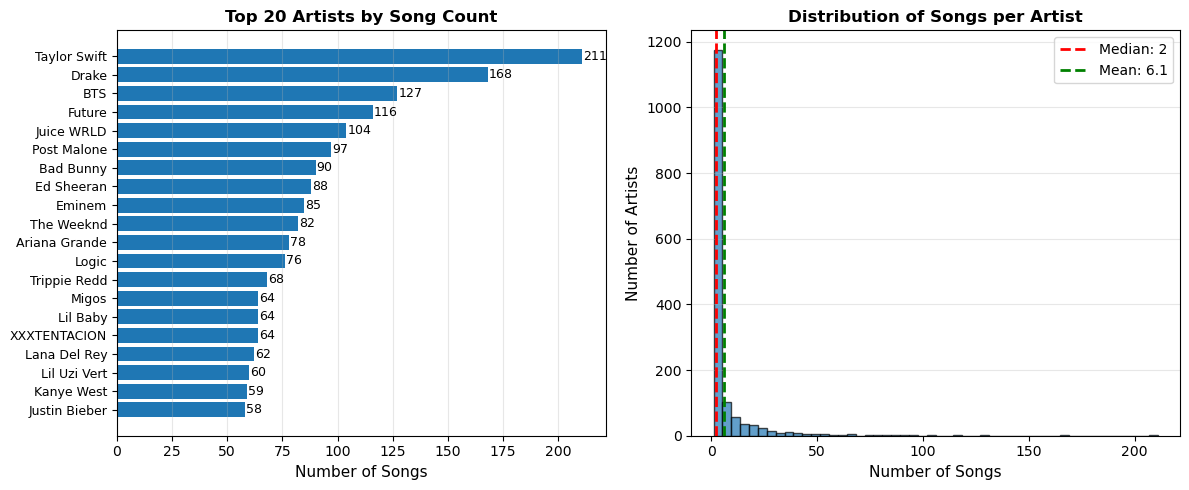

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ax1, ax2 = axes

# 1. Top 20 artists by song count
top_20 = artist_song_counts.head(20)
ax1.barh(range(len(top_20)), top_20.values)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20.index, fontsize=9)
ax1.set_xlabel('Number of Songs', fontsize=11)
ax1.set_title('Top 20 Artists by Song Count', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_20.values):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=9)

# 2. Distribution of songs per artist
ax2.hist(artist_song_counts.values, bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Songs', fontsize=11)
ax2.set_ylabel('Number of Artists', fontsize=11)
ax2.set_title('Distribution of Songs per Artist', fontsize=12, fontweight='bold')
ax2.axvline(artist_song_counts.median(), color='red', linestyle='--',
            linewidth=2, label=f'Median: {artist_song_counts.median():.0f}')
ax2.axvline(artist_song_counts.mean(), color='green', linestyle='--',
            linewidth=2, label=f'Mean: {artist_song_counts.mean():.1f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

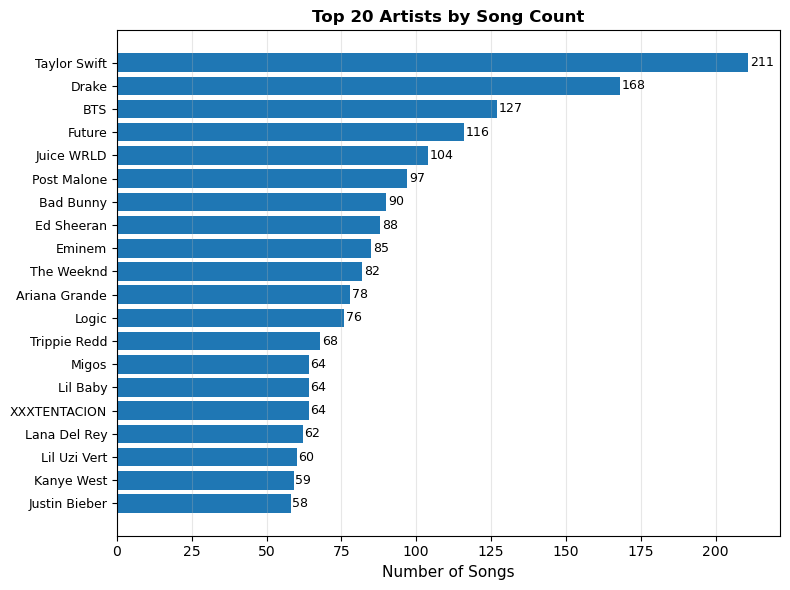

In [75]:
plt.figure(figsize=(8, 6))

top_20 = artist_song_counts.head(20)
plt.barh(range(len(top_20)), top_20.values)

plt.yticks(range(len(top_20)), top_20.index, fontsize=9)
plt.xlabel('Number of Songs', fontsize=11)
plt.title('Top 20 Artists by Song Count', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Label
for i, v in enumerate(top_20.values):
    plt.text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

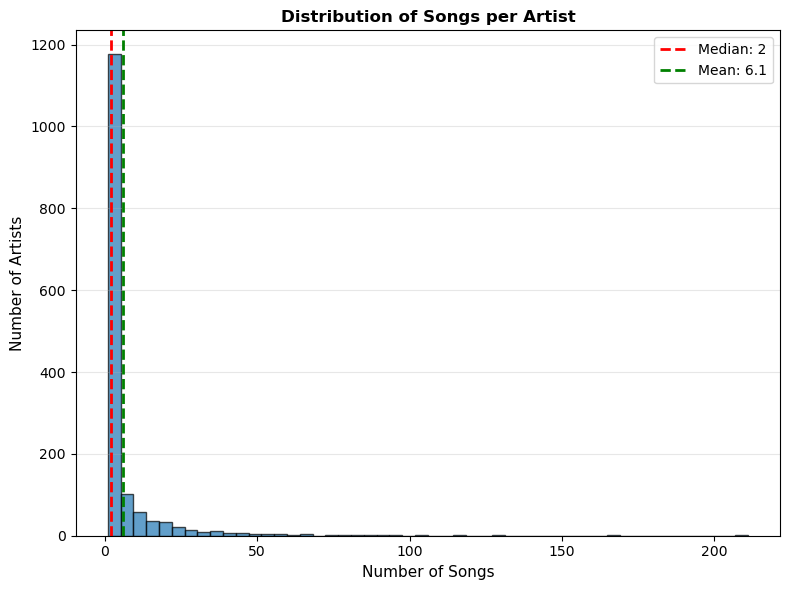

In [76]:
plt.figure(figsize=(8, 6))

plt.hist(artist_song_counts.values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Songs', fontsize=11)
plt.ylabel('Number of Artists', fontsize=11)
plt.title('Distribution of Songs per Artist', fontsize=12, fontweight='bold')

plt.axvline(artist_song_counts.median(), color='red', linestyle='--',
            linewidth=2, label=f'Median: {artist_song_counts.median():.0f}')
plt.axvline(artist_song_counts.mean(), color='green', linestyle='--',
            linewidth=2, label=f'Mean: {artist_song_counts.mean():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
audio_features = ['Danceability', 'Energy', 'Speechiness', 
                  'Acousticness', 'Instrumentalness', 
                  'Valence',  'Loudness_norm']

total_outliers = 0
outlier_counts = {}

for feature in audio_features:
    Q1 = data_all[feature].quantile(0.25)
    Q3 = data_all[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data_all[feature] < Q1 - 1.5*IQR) | (data_all[feature] > Q3 + 1.5*IQR)).sum()
    total_outliers += outliers
    outlier_counts[feature] = outliers
    print(f"{feature}: {outliers} outliers ({outliers/len(data_all)*100:.2f}%)")

outlier_percentage = (total_outliers / (len(data_all) * len(audio_features))) * 100
print(f"\nTotal outliers: {total_outliers}")


Danceability: 77 outliers (0.84%)
Energy: 128 outliers (1.40%)
Speechiness: 399 outliers (4.36%)
Acousticness: 399 outliers (4.36%)
Instrumentalness: 1400 outliers (15.28%)
Valence: 0 outliers (0.00%)
Loudness_norm: 350 outliers (3.82%)

Total outliers: 2753


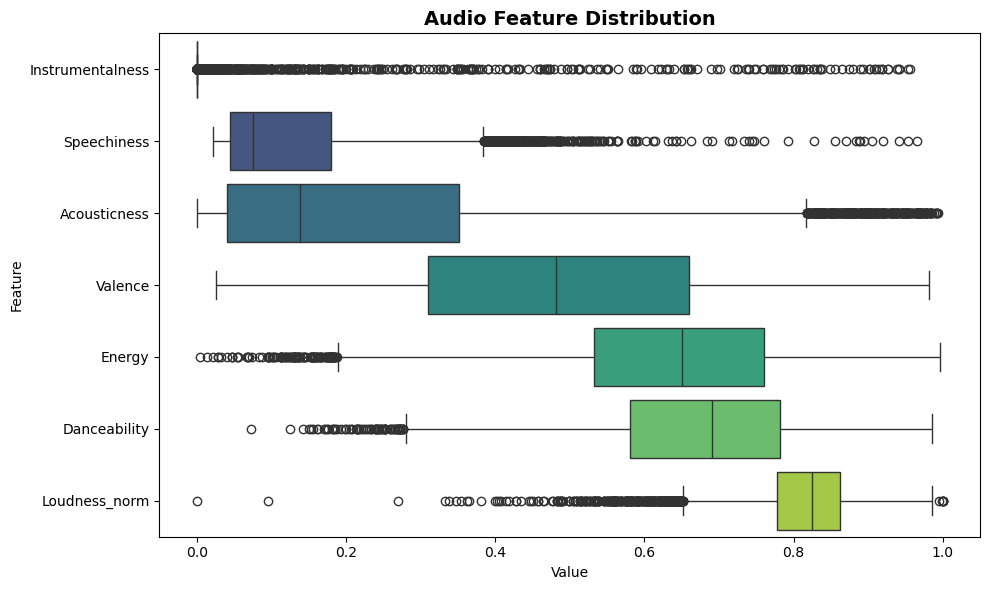

In [80]:
audio_features = [
    'Instrumentalness', 'Speechiness', 'Acousticness', 
    'Valence', 'Energy', 'Danceability', 'Loudness_norm'
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_all[audio_features],
    orient='h',           
    palette="viridis"        
)

plt.title("Audio Feature Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()